# Model Training

In [1]:
# !rm -rf /kaggle/working/*

In [2]:
import numpy as np
import pandas as pd
import os 
import json
from datetime import datetime

import hyperparameters
from utils import RandomTrial, read_data

In [3]:
from modelsnnpc_withproba import *

In [4]:
DATASET_LIST = ["Variant I"]
# DATASET_LIST = ["Base", "Variant I", "Variant II", "Variant III", "Variant IV", "Variant V"]
NUM_TRIALS = 1 #10
BEGIN_TRIAL = 0
BASE_SEED = 42

METRICS_NAME_GLOBAL = ["accuracy", "precision", "recall", "fpr", "f1_score","auc"]
METRICS_NAME_5FPR = ["accuracy@5FPR","precision@5FPR", "recall@5FPR", "fpr@5FPR", "f1_score@5FPR"]
METRICS_FAIRNESS = ["fpr_ratio_age", "fpr_ratio_income", "fpr_ratio_employment",
                   "eod_age", "eod_income", "eod_employment",
                   "aod_age", "aod_income", "aod_employment"]
# HYPERPARAMETERS = hyperparameters.P20_S50 
with open("/kaggle/input/get-best-hyperparams/model_2_hyperparameters_selected.json", "r") as file:
    HYPERPARAMETERS = json.load(file)[0]

EXPERIMENT_NAME = f"P{HYPERPARAMETERS['population']}-S{HYPERPARAMETERS['step']}-{NUM_TRIALS}trials-begin{BEGIN_TRIAL}"
FIXED_DATE = None

# SHAP Code

In [5]:
!pip install shap

In [6]:
# SHAP
import shap

#visuals
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
def dataset_loop_shap(train_df, test_df, dataset_name, trial_number, seed, path, runs):
    x_train = train_df.drop(columns=["fraud_bool"])
    y_train = train_df["fraud_bool"]
    x_test = test_df.drop(columns=["fraud_bool"])
    y_test = test_df["fraud_bool"]
    num_classes = len(np.unique(y_train))
    num_features = len(x_train.columns)
    class_weights = (1-HYPERPARAMETERS['weight'], HYPERPARAMETERS['weight'])
    model = ModelSNNPC(
        num_features=num_features,
        num_classes=num_classes,
        class_weights=class_weights,
        betas=HYPERPARAMETERS['beta'],
        slope=HYPERPARAMETERS['slope'],
        thresholds=HYPERPARAMETERS['threshold'],
        population=HYPERPARAMETERS['population'],
        batch_size=HYPERPARAMETERS['batch'],
        num_epochs=HYPERPARAMETERS['epoch'],
        num_steps=HYPERPARAMETERS['step'],
        adam_betas=HYPERPARAMETERS['adam_beta'],
        learning_rate=HYPERPARAMETERS['learning_rate'],
        verbose=0
    )
    model.fit(x_train, y_train)
    # predictions, targets, proba = model.predict(x_test, y_test)
    
    # np.savetxt(f"predictions_run{trial_number}.csv", predictions, delimiter=",", fmt="%d") 
    # np.savetxt(f"targets_run{trial_number}.csv", targets, delimiter=",", fmt="%d")
    # #np.savetxt(f"proba_run{trial_number}.csv", proba, delimiter="\t")  
    # metrics = model.evaluate(targets, predictions)
    # metrics_aequitas = model.evaluate_business_constraint(targets, predictions)
    # metrics.update(metrics_aequitas)
    # fairness_age = model.evaluate_fairness(x_test, targets, predictions, "customer_age", 50)
    # metrics.update({k+"_age": v for k, v in fairness_age.items()})
    # fairness_income = model.evaluate_fairness(x_test, targets, predictions, "income", 0.5)
    # metrics.update({k+"_income": v for k, v in fairness_income.items()})
    # fairness_employement = model.evaluate_fairness(x_test, targets, predictions, "employment_status", 3)
    # metrics.update({k+"_employment": v for k, v in fairness_employement.items()})
    # results = {}
    # results["dataset"] = dataset_name
    # results["trial"] = trial_number
    # results["seed"] = seed
    # for metric in METRICS_NAME_GLOBAL:
    #     results[metric] = metrics[metric]
    # for metric in METRICS_NAME_5FPR:
    #     results[metric] = metrics_aequitas[metric]
    # for metric in METRICS_FAIRNESS:
    #     results[metric] = metrics[metric]
    # csv_row = ','.join([str(x) for x in results.values()])
    # with open(path, "a") as f:
    #     f.write(f"{csv_row}\n")
    # prev_runs = runs.get(dataset_name, [])
    # prev_runs.append(results)
    # print(results)
    # runs[dataset_name] = prev_runs
    print("model_trained")
    
    return model, x_test, y_test

In [8]:
base_df_path = '/kaggle/input/snn-fraud-detection-model2-3/'
experiment_dir = f"/kaggle/working/explainability/"
results_path = f"{experiment_dir}/results.csv"
trial_number = 0
subset_size=500

os.makedirs(os.path.dirname(experiment_dir), exist_ok=True)

In [9]:
train_df = pd.read_csv(base_df_path+'train_dfs0.csv')
test_df = pd.read_csv(base_df_path+'test_dfs0.csv')

In [10]:
model, x_test, y_test = dataset_loop_shap(train_df, test_df, "Variant I", 0, 987231, results_path, {})

model_trained


In [11]:
x_test.shape

(205010, 31)

In [12]:
def shap_predict(x_test):
    y_test_filtered = y_test.loc[x_test.index]
    _, _, prediction_probs = model.predict(x_test, y_test_filtered)
    return np.array(prediction_probs)  # Return only the probabilities

In [13]:
explainer = shap.Explainer(shap_predict, x_test)
print("explainer created")

explainer created


In [14]:
sample_data = x_test.sample(n=subset_size, random_state=BASE_SEED)
shap_values = explainer(sample_data)
print("shap_values done")

PermutationExplainer explainer: 501it [48:09,  5.79s/it]

shap_values done


In [15]:
sample_data.to_csv(f"{experiment_dir}x_test_sample.csv")

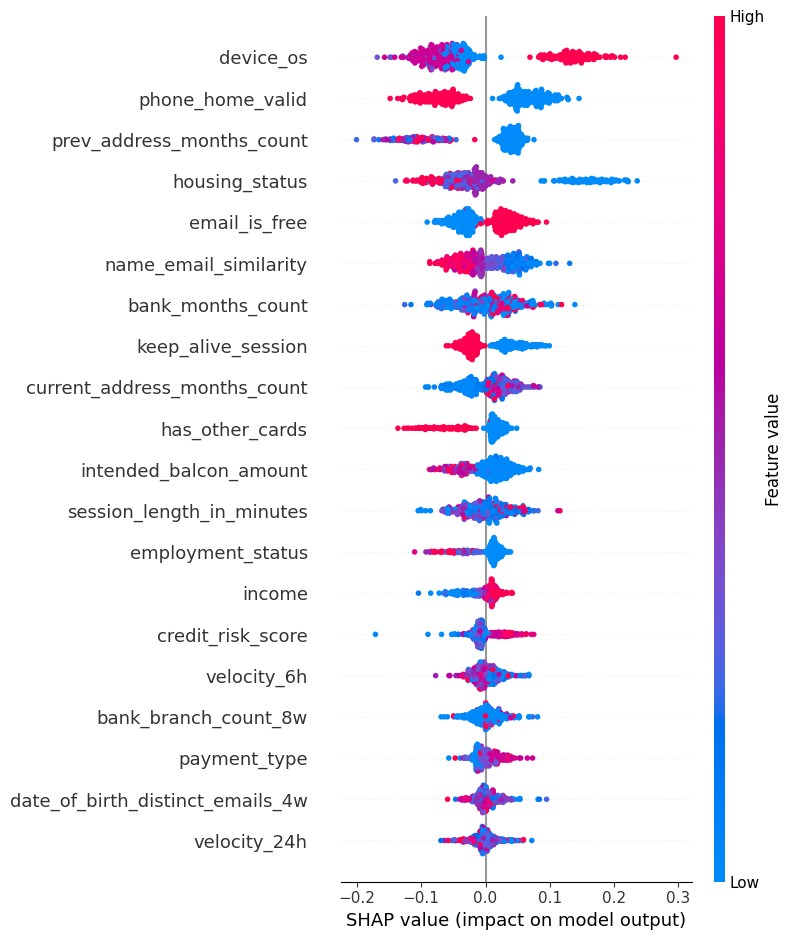

In [16]:
shap.summary_plot(shap_values[..., 1], sample_data, feature_names=sample_data.columns, max_display= 20, show=False)
plt.savefig(f"{experiment_dir}shap_summary_plot_class1.png", bbox_inches='tight')
plt.show()
plt.close()

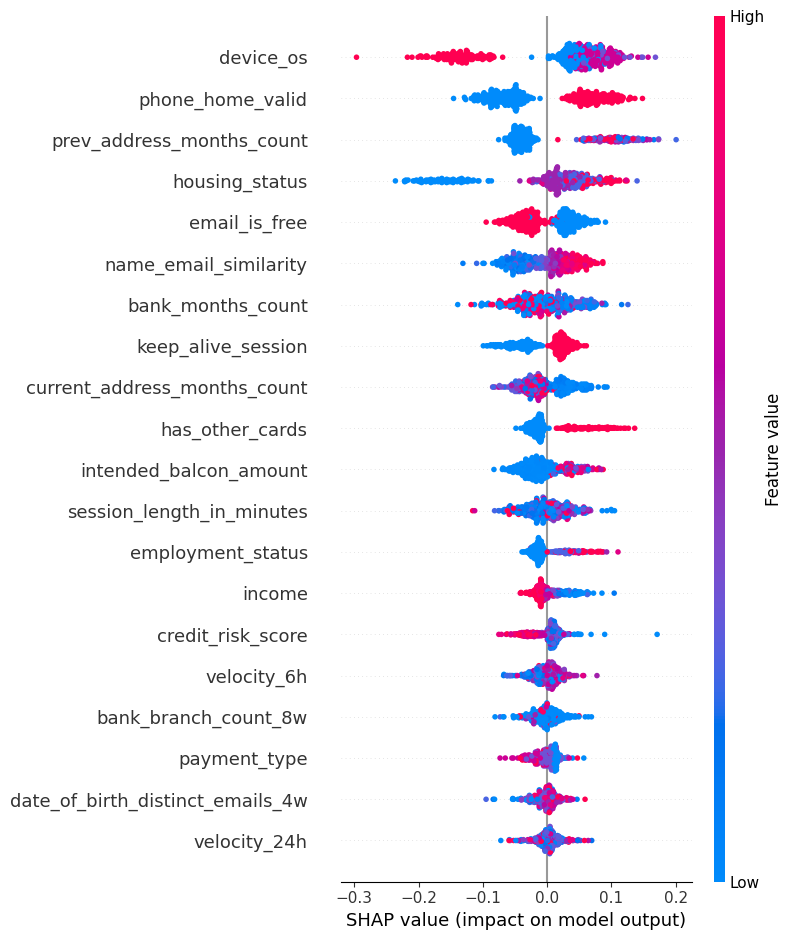

In [17]:
shap.summary_plot(shap_values[..., 0], sample_data, feature_names=sample_data.columns, max_display= 20, show=False)
plt.savefig(f"{experiment_dir}shap_summary_plot_class0.png", bbox_inches='tight')
plt.show()
plt.close()

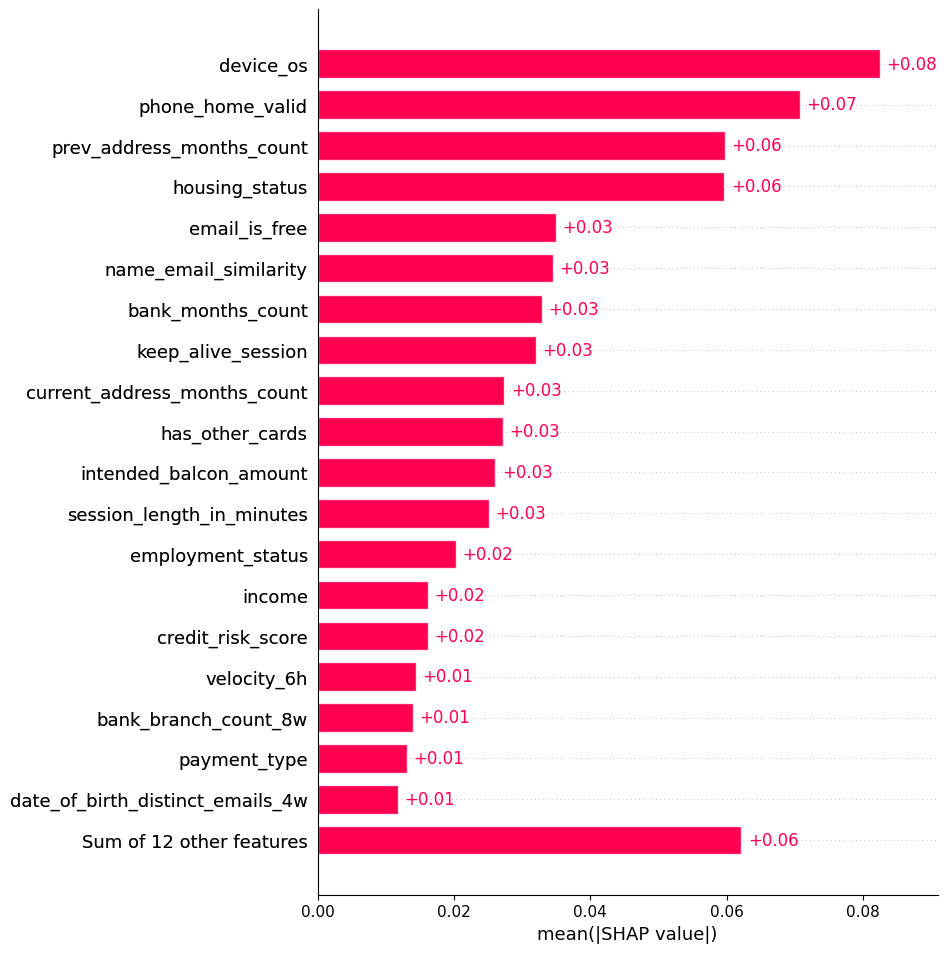

In [18]:
shap.plots.bar(shap_values[...,1], max_display= 20, show=False)
plt.savefig(f"{experiment_dir}shap_barplot_class1.png", bbox_inches='tight')
plt.show()
plt.close()

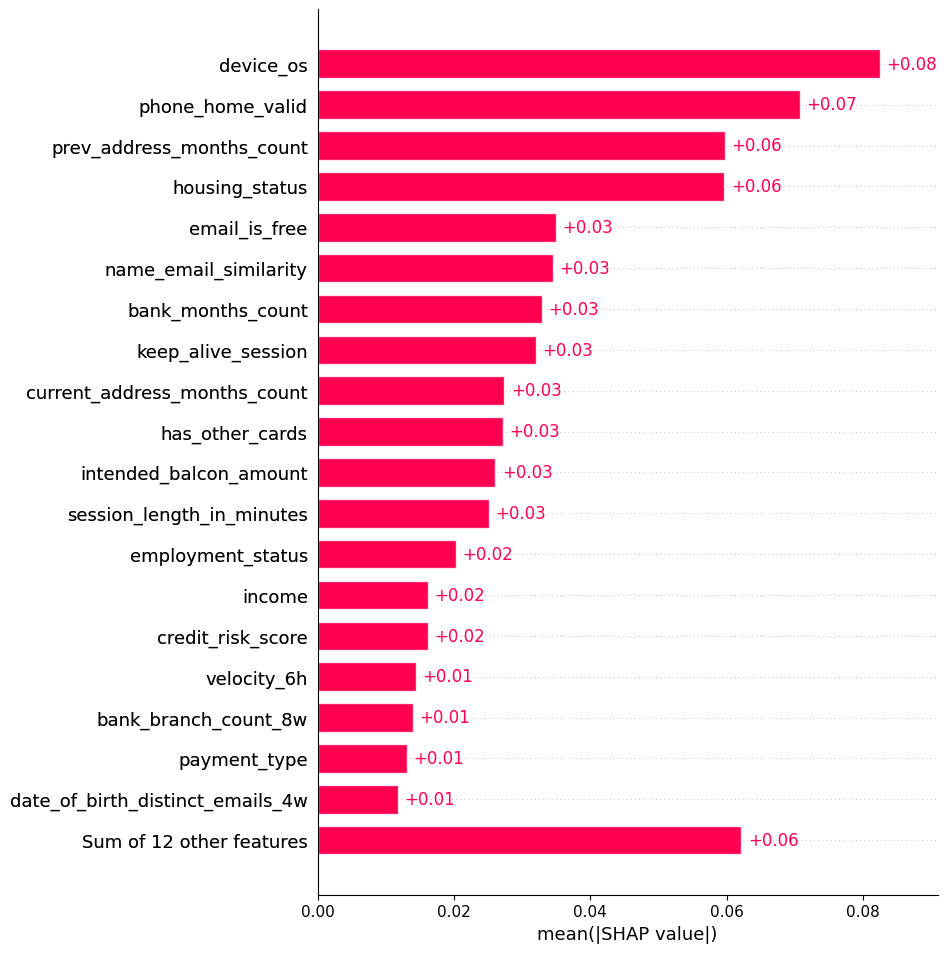

In [19]:
shap.plots.bar(shap_values[...,0], max_display= 20, show=False)
plt.savefig(f"{experiment_dir}shap_barplot_class0.png", bbox_inches='tight')
plt.show()
plt.close()

In [20]:
# def SHAP_testing(model, x_test, y_test):
#     predictions, targets, proba = model.predict(x_test, y_test)
#     class PrecomputedModel:
#         def __init__(self, proba_full):
#             self.proba = proba_full

#         def predict(self, x):
#             return self.proba[:len(x)]
#     dummy_model = PrecomputedModel(proba)
#     explainer = shap.Explainer(dummy_model.predict, x_test)
#     print("explainer created")
#     shap_values = explainer.shap_values(x_test)
#     print("shap_values done")
#     shap.plots.bar(shap_values, max_display= 20)
#     shap.summary_plot(shap_values, x_test, max_display= 20)
#     return shap_values

In [21]:
# shap_values = shap.summary_plot(SHAP_testing(model, x_test, y_test), x_test, max_display= 20)

In [22]:
# shap.summary_plot(SHAP_testing(model, x_test, y_test), x_test, max_display= 20)

In [23]:
# def simulation_shap(datasets, train_dfs, test_dfs, path="./results.csv"):
#     np.random.seed(BASE_SEED)
#     seeds = np.random.choice(list(range(1_000_000)), size=NUM_TRIALS, replace=False)
#     runs = {}
#     for trial in range(NUM_TRIALS):
#         seed = seeds[trial]
#         trial_number = trial
#         trial = RandomTrial(seed=seed)
#         if trial_number < BEGIN_TRIAL:
#             print(f"Skipping trial {trial_number} – seed {seed}")
#             continue
#         for dataset_name in datasets.keys():
#             print(f"Running trial {trial_number} with seed {seed} on dataset {dataset_name}")
#             runs = dataset_loop_shap(train_dfs, test_dfs, dataset_name, trial_number, seed, path, runs)
#     return runs

In [24]:
# simulation_shap(datasets, train_dfs, test_dfs, path=results_path)